In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'Arial'
plt.style.use('seaborn-v0_8-talk')

In [2]:
import numpy as np
import pandas as pd
import torch
import gpytorch
from sklearn.linear_model import LogisticRegression
from joblib import Parallel, delayed
from collections import defaultdict
from tqdm.auto import tqdm

class BatchedExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, num_features, batch_shape):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=batch_shape)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=num_features, batch_shape=batch_shape),
            batch_shape=batch_shape,
        )

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(self.mean_module(x), self.covar_module(x))


class IntegratedHurdlePipeline:
    def __init__(self, gene_names, num_features=10, device=None):
        self.gene_names = np.array(gene_names)
        self.num_features = num_features
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Per-gene result registry keyed by gene name.
        self.gene_registry = {gene: {} for gene in self.gene_names}
        # Batched GP models keyed by positive-sample count bucket.
        self.batched_gp_models = {}

    def _fit_logistic_single(self, gene_name, y_raw, X_scaled):
        n_samples, n_pos = len(y_raw), (y_raw > 0).sum()
        res = {'n_pos': n_pos, 'total': n_samples}

        # Sparsity condition routing (0% 발현 예외 처리 추가)
        if n_pos == n_samples:
            res.update({'status': 'Always_Expressed', 'lr_model': None})
        elif n_pos == 0:
            # 정상군에서 단 한 번도 관측되지 않은 유전자
            res.update({'status': 'Never_Expressed', 'lr_model': None})
        else:
            res['status'] = 'LR_Only' if n_pos < 50 else 'Track_A_and_B'
            res['lr_model'] = LogisticRegression(max_iter=1000).fit(X_scaled, (y_raw > 0).astype(int))
        return gene_name, res

    def fit_track_A_cpu(self, X_train_hc, Y_train_hc):
        jobs = (
            delayed(self._fit_logistic_single)(self.gene_names[i], Y_train_hc[:, i], X_train_hc)
            for i in range(len(self.gene_names))
        )
        results = []
        status_counts = defaultdict(int)
        
        with Parallel(n_jobs=-1, return_as="generator") as parallel:
            for g_name, res in tqdm(parallel(jobs), total=len(self.gene_names), desc="Track A (CPU)", unit="gene"):
                results.append((g_name, res))
                
        for g_name, res in results:
            self.gene_registry[g_name].update(res)
            status_counts[res['status']] += 1
            
        print(f"Summary: {dict(status_counts)}\n")

    def fit_track_B_gpu(self, X_train_hc, Y_train_hc, epochs=50, lr=0.1):
        buckets = defaultdict(list)
        for g_idx, gene_name in enumerate(self.gene_names):
            reg = self.gene_registry[gene_name]
            if reg.get('status') == 'Track_A_and_B':
                buckets[reg['n_pos']].append((g_idx, gene_name))

        n_buckets = len(buckets.items())
        for idx, (n_pos, gene_tuples) in enumerate(buckets.items()):
            g_indices = [idx for idx, _ in gene_tuples]
            g_names = [name for _, name in gene_tuples]
            batch_size = len(g_indices)
            
            # 1. Extract raw positive expressions
            X_batch = [X_train_hc[Y_train_hc[:, g_idx] > 0] for g_idx in g_indices]
            Y_raw = np.stack([np.log1p(Y_train_hc[Y_train_hc[:, g_idx] > 0, g_idx]) for g_idx in g_indices])

            # 2. Gene-wise Y-Scaling (Critical for GP Convergence)
            # Y_raw shape: (batch_size, n_pos) -> mean/std shape: (batch_size,)
            Y_mean = Y_raw.mean(axis=1)
            Y_std = Y_raw.std(axis=1) + 1e-6
            
            # Broadcasting for standard scaling
            Y_scaled = (Y_raw - Y_mean[:, None]) / Y_std[:, None]

            # 3. Tensor Assembly
            X_tensor = torch.tensor(np.stack(X_batch), dtype=torch.float32, device=self.device)
            Y_tensor = torch.tensor(Y_scaled, dtype=torch.float32, device=self.device)

            batch_shape = torch.Size([batch_size])
            likelihood = gpytorch.likelihoods.GaussianLikelihood(batch_shape=batch_shape).to(self.device)
            model = BatchedExactGPModel(X_tensor, Y_tensor, likelihood, self.num_features, batch_shape).to(self.device)

            model.train()
            likelihood.train()
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
            
            initial_loss, final_loss = 0, 0

            for epoch in range(epochs):
                optimizer.zero_grad()
                loss = -mll(model(X_tensor), Y_tensor).sum()
                loss.backward()
                optimizer.step()
                
                if epoch == 0: initial_loss = loss.item()
                if epoch == epochs - 1: final_loss = loss.item()

            # 4. Save trained models AND scaling parameters
            self.batched_gp_models[n_pos] = {
                'model': model.eval().cpu(),
                'likelihood': likelihood.eval().cpu(),
                'gene_names': g_names,
                'y_mean': Y_mean,  # Shape: (batch_size,)
                'y_std': Y_std     # Shape: (batch_size,)
            }
            tqdm.write(f"   ▶ Batch [{idx+1:03d}/{n_buckets:03d}] | N_pos: {n_pos:4d} | Genes: {batch_size:4d} | Loss Drop: {initial_loss:.1f} → {final_loss:.1f}")

    def predict_disease(self, gene_name, X_disease, Y_disease_raw):
        """Return per-sample Z-scores for a single gene in disease samples."""
        reg = self.gene_registry.get(gene_name)
        if reg is None:
            return None

        status = reg['status']
        res = {'status': status, 'Z_state': None, 'Z_quant': None, 'Z_total': None}

        # Sparse anomaly routing
        if status == 'Always_Expressed':
            res['Z_state'] = np.where(Y_disease_raw == 0, -99.0, 0.0)
            return res
        if status == 'Never_Expressed':
            res['Z_state'] = np.where(Y_disease_raw > 0, 99.0, 0.0)
            return res
        
        # Logistic track inference
        prob_detection = reg['lr_model'].predict_proba(X_disease)[:, 1]
        is_detected = (Y_disease_raw > 0).astype(int)
        res['Z_state'] = (is_detected - prob_detection) / np.sqrt(prob_detection * (1 - prob_detection) + 1e-6)

        if status == 'LR_Only':
            res['Z_total'] = res['Z_state']
            return res

        # GP track inference
        n_pos = reg['n_pos']
        batch_info = self.batched_gp_models[n_pos]
        local_idx = batch_info['gene_names'].index(gene_name)
        
        # 1. Retrieve normalization parameters
        y_m = batch_info['y_mean'][local_idx]
        y_s = batch_info['y_std'][local_idx]

        model = batch_info['model'].to(self.device)
        likelihood = batch_info['likelihood'].to(self.device)
        X_test = torch.tensor(X_disease, dtype=torch.float32, device=self.device).unsqueeze(0)

        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            pred = likelihood(model(X_test.expand(len(batch_info['gene_names']), -1, -1)))
            mu = pred.mean[local_idx].cpu().numpy()
            std = torch.sqrt(pred.variance[local_idx]).cpu().numpy()

        # 2. Scale inference data and calculate Z-quant
        z_quant = np.full(len(Y_disease_raw), np.nan)
        pos_mask = Y_disease_raw > 0
        
        if pos_mask.any():
            Y_disease_log = np.log1p(Y_disease_raw[pos_mask])
            Y_disease_scaled = (Y_disease_log - y_m) / y_s
            z_quant[pos_mask] = (Y_disease_scaled - mu[pos_mask]) / std[pos_mask]

        res['Z_quant'] = z_quant
        model.cpu(); likelihood.cpu()
        return res


In [16]:
import numpy as np
import scanpy as sc
from sklearn.preprocessing import StandardScaler
from scipy.sparse import issparse, csc_matrix

# Load data and keep QC-passed samples only.
adata = sc.read_h5ad('OpenAccess_nfcore/Merged_Processed_AnnData_with_Batch_Biases_QC_Status.h5ad')
adata = adata[adata.obs['QC_Passed'] == True]

bias_columns = [
    'log(Total Reads)', 'Spliced Reads (%)', 'gDNA Contamination (Intron/Exon)',
    'rRNA Fraction', "RNA Degradation (3' Bias)", 'Platelet Score',
    'GC Bias', 'Gene Length Bias', 'NG80', '(NP80/NG80)'
]

phenotypes = adata.obs['Phenotype_Processed'].astype(str).values
is_hc = phenotypes == 'Healthy Control'
X_raw = adata.obs[bias_columns].values

# Fit scaler on healthy controls to avoid leakage.
scaler = StandardScaler()
X_hc_scaled = scaler.fit_transform(X_raw[is_hc])

# Use CSC for sparse matrices to speed up per-gene column access.
Y_layer = adata.layers['CPM_log1p']
Y_matrix = csc_matrix(Y_layer) if issparse(Y_layer) else np.asfortranarray(Y_layer)

dataset = {
    'HC': {'X': X_hc_scaled, 'Y': Y_matrix[is_hc, :]},
    'Disease': {},
    'is_sparse': issparse(Y_layer),
}

# Split disease cohorts using the same scaler.
for disease in np.unique(phenotypes[~is_hc]):
    mask = phenotypes == disease
    dataset['Disease'][disease] = {
        'X': scaler.transform(X_raw[mask]),
        'Y': Y_matrix[mask, :],
    }

In [17]:
pipeline = IntegratedHurdlePipeline(
    gene_names=adata.var_names, 
    num_features=len(bias_columns)
)

### Test : Small Batches

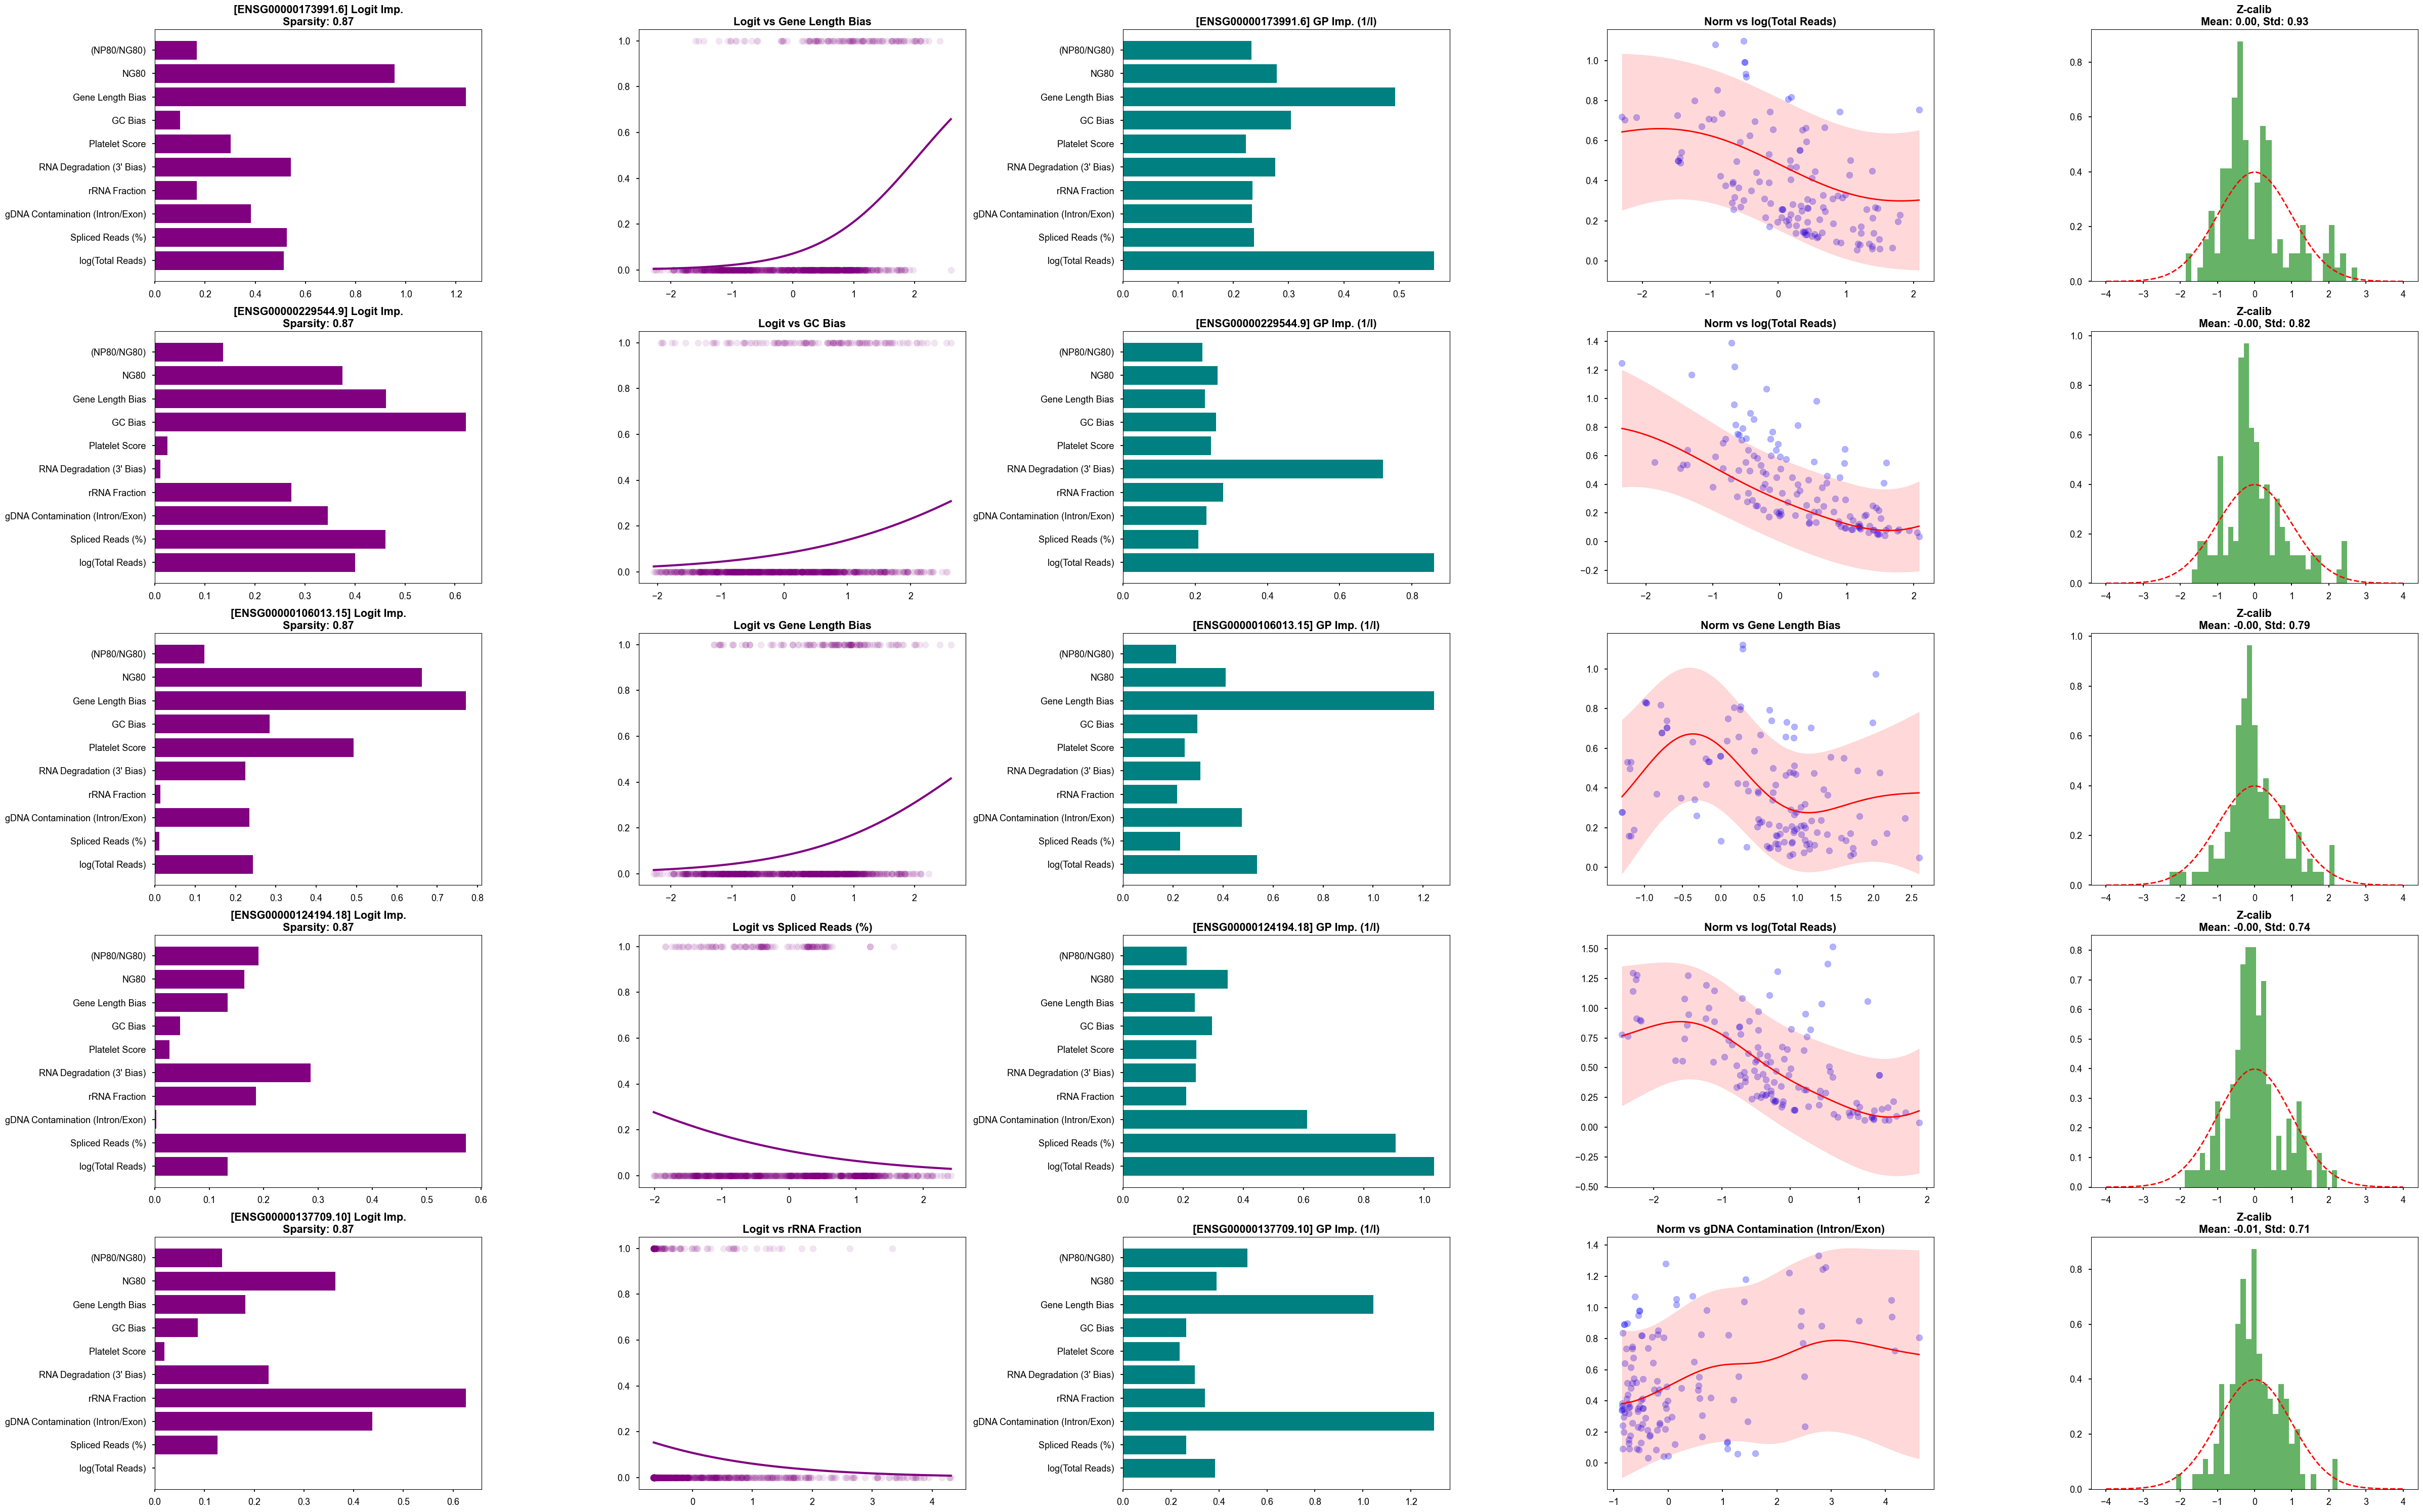

In [11]:
from scipy.stats import norm

# 1. Subsample Data: 5 batches x 10 genes based on identical N_pos
Y_hc_dense = dataset['HC']['Y'].toarray() if dataset['is_sparse'] else dataset['HC']['Y']
n_pos_array = (Y_hc_dense > 0).sum(axis=0)

buckets = defaultdict(list)
for i, n_pos in enumerate(n_pos_array):
    if n_pos >= 50:  
        buckets[n_pos].append(i)

valid_n_pos = [n for n, idxs in buckets.items() if len(idxs) >= 10]
if len(valid_n_pos) < 5:
    raise ValueError("Insufficient gene batches. Reduce criteria.")

np.random.seed(42)
selected_n_pos = np.random.choice(valid_n_pos, 5, replace=False)
test_indices = [idx for n in selected_n_pos for idx in np.random.choice(buckets[n], 10, replace=False)]

test_genes = adata.var_names[test_indices]
Y_hc_test = Y_hc_dense[:, test_indices]
X_hc = dataset['HC']['X']

# 2. Initialize and Train Pipeline
pipeline = IntegratedHurdlePipeline(gene_names=test_genes, num_features=len(bias_columns))
pipeline.fit_track_A_cpu(X_hc, Y_hc_test)
pipeline.fit_track_B_gpu(X_hc, Y_hc_test, epochs=50)

# 3. 5-Panel Training Diagnostics Visualization
def plot_training_diagnostics(pipeline, plot_genes, X_train, Y_train_dense, bias_cols):
    valid_genes = [g for g in plot_genes if pipeline.gene_registry.get(g, {}).get('status') == 'Track_A_and_B']
    if not valid_genes: return

    fig, axes = plt.subplots(nrows=len(valid_genes), ncols=5, figsize=(48, 6 * len(valid_genes)))
    if len(valid_genes) == 1: axes = [axes]

    for i, g_name in enumerate(valid_genes):
        ax = axes[i]
        reg = pipeline.gene_registry[g_name]
        g_idx = np.where(pipeline.gene_names == g_name)[0][0]
        
        y_raw = Y_train_dense[:, g_idx]
        is_pos = y_raw > 0
        X_pos, Y_pos = X_train[is_pos], np.log1p(y_raw[is_pos])

        # Track A (Logistic) Extraction
        lr_model = reg['lr_model']
        l_coefs = lr_model.coef_[0]
        top_l_idx = np.argmax(np.abs(l_coefs))
        
        x_l_range = np.linspace(X_train[:, top_l_idx].min(), X_train[:, top_l_idx].max(), 100)
        X_dummy_l = np.zeros((100, len(bias_cols)))
        X_dummy_l[:, top_l_idx] = x_l_range
        prob_curve = lr_model.predict_proba(X_dummy_l)[:, 1]

        # Track B (GP) Extraction
        b_info = pipeline.batched_gp_models[reg['n_pos']]
        l_idx = b_info['gene_names'].index(g_name)
        model, likelihood = b_info['model'].to(pipeline.device), b_info['likelihood'].to(pipeline.device)

        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            l_scales = model.covar_module.base_kernel.lengthscale[l_idx].cpu().squeeze().numpy()
            gp_imp = 1.0 / l_scales
            top_g_idx = np.argmax(gp_imp)

            X_t = torch.tensor(X_pos, dtype=torch.float32).unsqueeze(0).to(pipeline.device)
            pred_train = likelihood(model(X_t.expand(len(b_info['gene_names']), -1, -1)))
            mu_train, std_train = pred_train.mean[l_idx].cpu().numpy(), torch.sqrt(pred_train.variance[l_idx]).cpu().numpy()
            z_scores = (Y_pos - mu_train) / std_train

            x_g_range = np.linspace(X_pos[:, top_g_idx].min(), X_pos[:, top_g_idx].max(), 100)
            X_dummy_g = np.zeros((len(b_info['gene_names']), 100, len(bias_cols)))
            X_dummy_g[l_idx, :, top_g_idx] = x_g_range
            pred_dummy = likelihood(model(torch.tensor(X_dummy_g, dtype=torch.float32).to(pipeline.device)))
            mu_dummy, std_dummy = pred_dummy.mean[l_idx].cpu().numpy(), torch.sqrt(pred_dummy.variance[l_idx]).cpu().numpy()

        model.cpu(); likelihood.cpu()

        # Render Panels
        ax[0].barh(bias_cols, np.abs(l_coefs), color='purple')
        ax[0].set_title(f"[{g_name}] Logit Imp.\nSparsity: {1 - (reg['n_pos']/len(y_raw)):.2f}", fontweight='bold')

        ax[1].scatter(X_train[:, top_l_idx], is_pos.astype(int), color='purple', alpha=0.1)
        ax[1].plot(x_l_range, prob_curve, color='purple', lw=3)
        ax[1].set_title(f"Logit vs {bias_cols[top_l_idx]}", fontweight='bold')

        ax[2].barh(bias_cols, gp_imp, color='teal')
        ax[2].set_title(f"[{g_name}] GP Imp. (1/l)", fontweight='bold')

        ax[3].scatter(X_pos[:, top_g_idx], Y_pos, color='blue', alpha=0.3)
        ax[3].plot(x_g_range, mu_dummy, color='red', lw=2)
        ax[3].fill_between(x_g_range, mu_dummy - 1.96*std_dummy, mu_dummy + 1.96*std_dummy, color='red', alpha=0.15)
        ax[3].set_title(f"Norm vs {bias_cols[top_g_idx]}", fontweight='bold')

        ax[4].hist(z_scores, bins=30, density=True, alpha=0.6, color='green')
        x_axis = np.linspace(-4, 4, 100)
        ax[4].plot(x_axis, norm.pdf(x_axis, 0, 1), 'r--', lw=2)
        ax[4].set_title(f"Z-calib\nMean: {np.mean(z_scores):.2f}, Std: {np.std(z_scores):.2f}", fontweight='bold')

    plt.tight_layout()
    plt.show()

# Visualize the first 5 genes to check training stability
plot_training_diagnostics(pipeline, test_genes[:5], X_hc, Y_hc_test, bias_columns)

### Trial : Protein Coding Gene 

In [3]:
def save_pipeline(pipeline, prefix="./Saved_Pipeline/cfRNA_GP_Norm"):
    import joblib
    joblib.dump(pipeline.gene_registry, f"{prefix}_registry.pkl")
    gp_states = {}
    for n_pos, b_info in pipeline.batched_gp_models.items():
        gp_states[n_pos] = {
            'model_state': b_info['model'].state_dict(),
            'likelihood_state': b_info['likelihood'].state_dict(),
            'gene_names': b_info['gene_names']
        }
    torch.save(gp_states, f"{prefix}_gp_states.pt")
    print(f"Pipeline successfully saved with prefix: {prefix}")
    
def load_pipeline(prefix, gene_names, num_features, device):
    import joblib
    pipeline = IntegratedHurdlePipeline(gene_names, num_features, device)    
    pipeline.gene_registry = joblib.load(f"{prefix}_registry.pkl")
    
    # Load GP states
    gp_states = torch.load(f"{prefix}_gp_states.pt", map_location=device, weights_only=False)
    for n_pos, state in gp_states.items():
        b_shape = torch.Size([len(state['gene_names'])])
        likelihood = gpytorch.likelihoods.GaussianLikelihood(batch_shape=b_shape).to(device)
        model = BatchedExactGPModel(
            torch.zeros(1, 1, num_features), # Dummy init, will be overwritten by state_dict
            torch.zeros(1, 1), 
            likelihood, num_features, b_shape
        ).to(device)
        
        model.load_state_dict(state['model_state'])
        likelihood.load_state_dict(state['likelihood_state'])
        
        pipeline.batched_gp_models[n_pos] = {
            'model': model.eval().cpu(),
            'likelihood': likelihood.eval().cpu(),
            'gene_names': state['gene_names']
        }
        
    print(f"Pipeline successfully loaded from prefix: {prefix}")
    return pipeline

In [4]:
is_protein_coding = adata.var['GeneType'] == 'protein_coding'
pc_gene_names = adata.var_names[is_protein_coding]
pc_indices = np.where(is_protein_coding)[0]

Y_hc_pc = dataset['HC']['Y'][:, pc_indices]

if dataset['is_sparse']:
    Y_hc_pc = Y_hc_pc.toarray()
X_hc = dataset['HC']['X']

NameError: name 'adata' is not defined

In [20]:
# 2. Initialize and Train Pipeline
print("\nTraining Pipeline on Protein Coding Genes...")
pipeline = IntegratedHurdlePipeline(gene_names=pc_gene_names, num_features=len(bias_columns))
pipeline.fit_track_A_cpu(X_hc, Y_hc_pc)
pipeline.fit_track_B_gpu(X_hc, Y_hc_pc, epochs=75)


Training Pipeline on Protein Coding Genes...


Track A (CPU):   0%|          | 0/20097 [00:00<?, ?gene/s]

Summary: {'Track_A_and_B': 17777, 'Always_Expressed': 613, 'LR_Only': 1650, 'Never_Expressed': 57}

   ▶ Batch [001/946] | N_pos:  557 | Genes:    7 | Loss Drop: 9.3 → 8.2
   ▶ Batch [002/946] | N_pos:  153 | Genes:   17 | Loss Drop: 23.2 → 19.4
   ▶ Batch [003/946] | N_pos:  975 | Genes:  115 | Loss Drop: 145.9 → 117.2
   ▶ Batch [004/946] | N_pos:  945 | Genes:   45 | Loss Drop: 57.4 → 48.4
   ▶ Batch [005/946] | N_pos:  865 | Genes:   22 | Loss Drop: 28.6 → 25.0
   ▶ Batch [006/946] | N_pos:  825 | Genes:   17 | Loss Drop: 22.4 → 19.8
   ▶ Batch [007/946] | N_pos:  884 | Genes:   26 | Loss Drop: 33.5 → 28.8
   ▶ Batch [008/946] | N_pos:  981 | Genes:  146 | Loss Drop: 183.3 → 135.6
   ▶ Batch [009/946] | N_pos:  737 | Genes:   12 | Loss Drop: 15.4 → 13.2
   ▶ Batch [010/946] | N_pos:  952 | Genes:   56 | Loss Drop: 71.5 → 60.4
   ▶ Batch [011/946] | N_pos:  985 | Genes:  173 | Loss Drop: 217.0 → 161.3
   ▶ Batch [012/946] | N_pos:  755 | Genes:   14 | Loss Drop: 18.4 → 16.3
   ▶ Bat

In [22]:
save_pipeline(pipeline,"./Saved_Pipelines/cfRNA_GP_Norm")

Pipeline successfully saved with prefix: ./Saved_Pipelines/cfRNA_GP_Norm


In [10]:
pipeline = load_pipeline(prefix="./Saved_Pipelines/cfRNA_GP_Norm", gene_names=pc_gene_names, num_features=10, device='cuda')

Pipeline successfully loaded from prefix: ./Saved_Pipelines/cfRNA_GP_Norm


In [23]:
import gc
def evaluate_global_fitness_safe(pipeline, X_train, Y_train_dense):
    print("🔍 Scanning GP models for 20,000+ genes (VRAM Safe Mode)...")
    records = []
    
    for n_pos, b_info in tqdm(pipeline.batched_gp_models.items(), desc="Evaluating", unit="batch"):
        model = b_info['model'].to(pipeline.device)
        likelihood = b_info['likelihood'].to(pipeline.device)
        g_names = b_info['gene_names']
        idx = [np.where(pipeline.gene_names == g)[0][0] for g in g_names]
        X_batch = np.stack([X_train[Y_train_dense[:, i] > 0] for i in idx])
        Y_batch = np.stack([np.log1p(Y_train_dense[Y_train_dense[:, i] > 0, i]) for i in idx])
        
        X_t = torch.tensor(X_batch, dtype=torch.float32).to(pipeline.device)
        
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            pred = likelihood(model(X_t))
            mu = pred.mean.cpu().numpy()
            std = torch.sqrt(pred.variance).cpu().numpy()
            noise_var = np.atleast_1d(likelihood.noise.detach().cpu().numpy().squeeze())
            
        Z = (Y_batch - mu) / std
        z_mean, z_std = np.mean(Z, axis=1), np.std(Z, axis=1)
            
        for j, g in enumerate(g_names):
            records.append((g, n_pos, noise_var[j], z_mean[j], z_std[j]))
            
        model.cpu()
        likelihood.cpu()
        del X_t, pred 
        torch.cuda.empty_cache() 
        gc.collect() 
        
    df_metrics = pd.DataFrame(records, columns=['Gene', 'N_pos', 'Noise_Var', 'Z_Mean', 'Z_Std'])
    return df_metrics

# --- 실행 ---
df_metrics = evaluate_global_fitness_safe(pipeline, X_hc, Y_hc_pc)

🔍 Scanning GP models for 20,000+ genes (VRAM Safe Mode)...


Evaluating:   0%|          | 0/946 [00:00<?, ?batch/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 716.00 MiB. GPU 0 has a total capacity of 23.99 GiB of which 0 bytes is free. Of the allocated memory 52.75 GiB is allocated by PyTorch, and 137.82 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

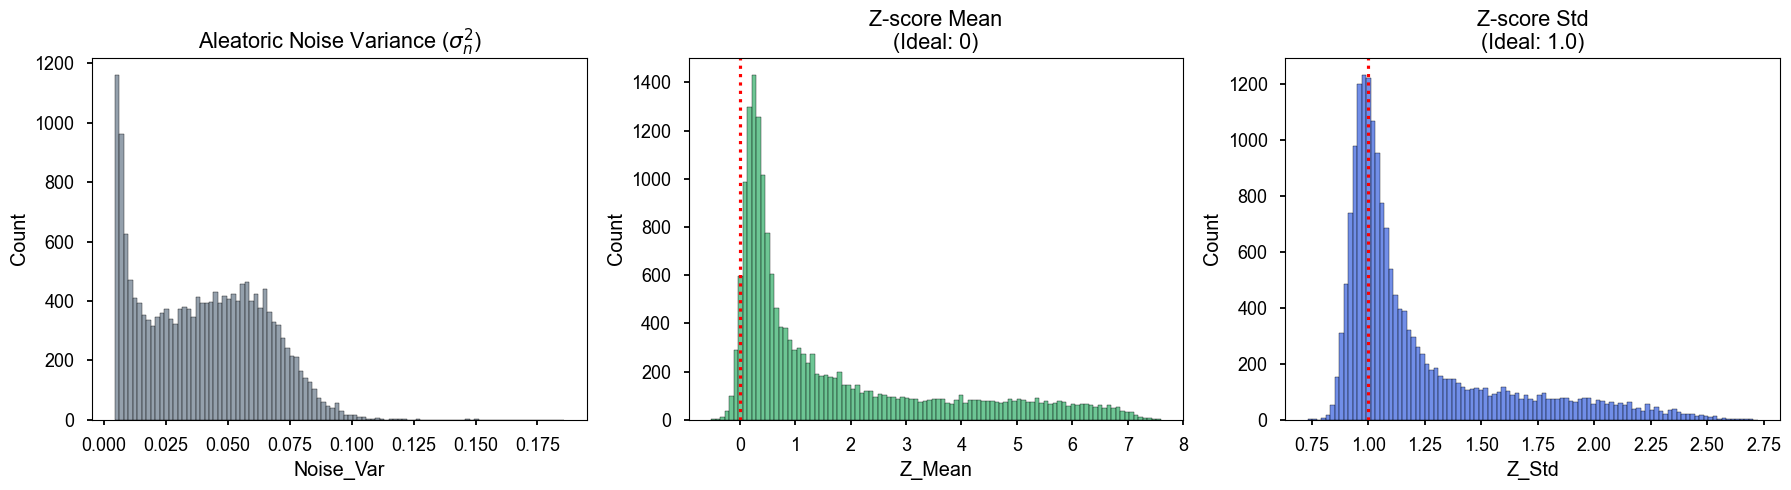

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_metrics['Noise_Var'], bins=100, color='slategray', ax=axes[0])
axes[0].set_title("Aleatoric Noise Variance ($\sigma_n^2$)")

sns.histplot(df_metrics['Z_Mean'], bins=100, color='mediumseagreen', ax=axes[1])
axes[1].axvline(0, color='red', linestyle=':')
axes[1].set_title("Z-score Mean\n(Ideal: 0)")

sns.histplot(df_metrics['Z_Std'], bins=100, color='royalblue', ax=axes[2])
axes[2].axvline(1.0, color='red', linestyle=':')
axes[2].set_title("Z-score Std\n(Ideal: 1.0)")

plt.tight_layout()
plt.show()

In [13]:
df_metrics

,Gene,N_pos,Noise_Var,Z_Mean,Z_Std
0,ENSG00000000003.17,557,0.060624,0.185850,0.939849
1,ENSG00000158714.12,557,0.065895,0.398880,1.108337
2,ENSG00000164898.13,557,0.043037,0.543655,1.160418
3,ENSG00000170293.10,557,0.054117,0.268627,1.043170
4,ENSG00000176927.16,557,0.050400,0.360628,0.879106
...,...,...,...,...,...
17772,ENSG00000221886.5,334,0.056295,0.236210,1.017066
17773,ENSG00000244355.8,334,0.033519,0.681724,1.099483
17774,ENSG00000285253.1,334,0.057074,0.521915,0.941160
17775,ENSG00000204172.12,615,0.072270,0.365683,1.025463
